### **Q16.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

sns.set_theme()

%matplotlib inline

In [3]:
from ISLP import confusion_table
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [4]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [5]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [6]:
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


First we'll create a variable `crim01` which indicates whether the crime rate is below (0) or above (1) the median.

In [7]:
boston['crim01'] = (boston['crim'] > boston['crim'].median()).astype(int)
boston['crim01'].sample(5, random_state=1)

307    0
343    0
47     0
67     0
362    1
Name: crim01, dtype: int64

Now we'll explore the data to see what features would be useful in predicting `crim01`.

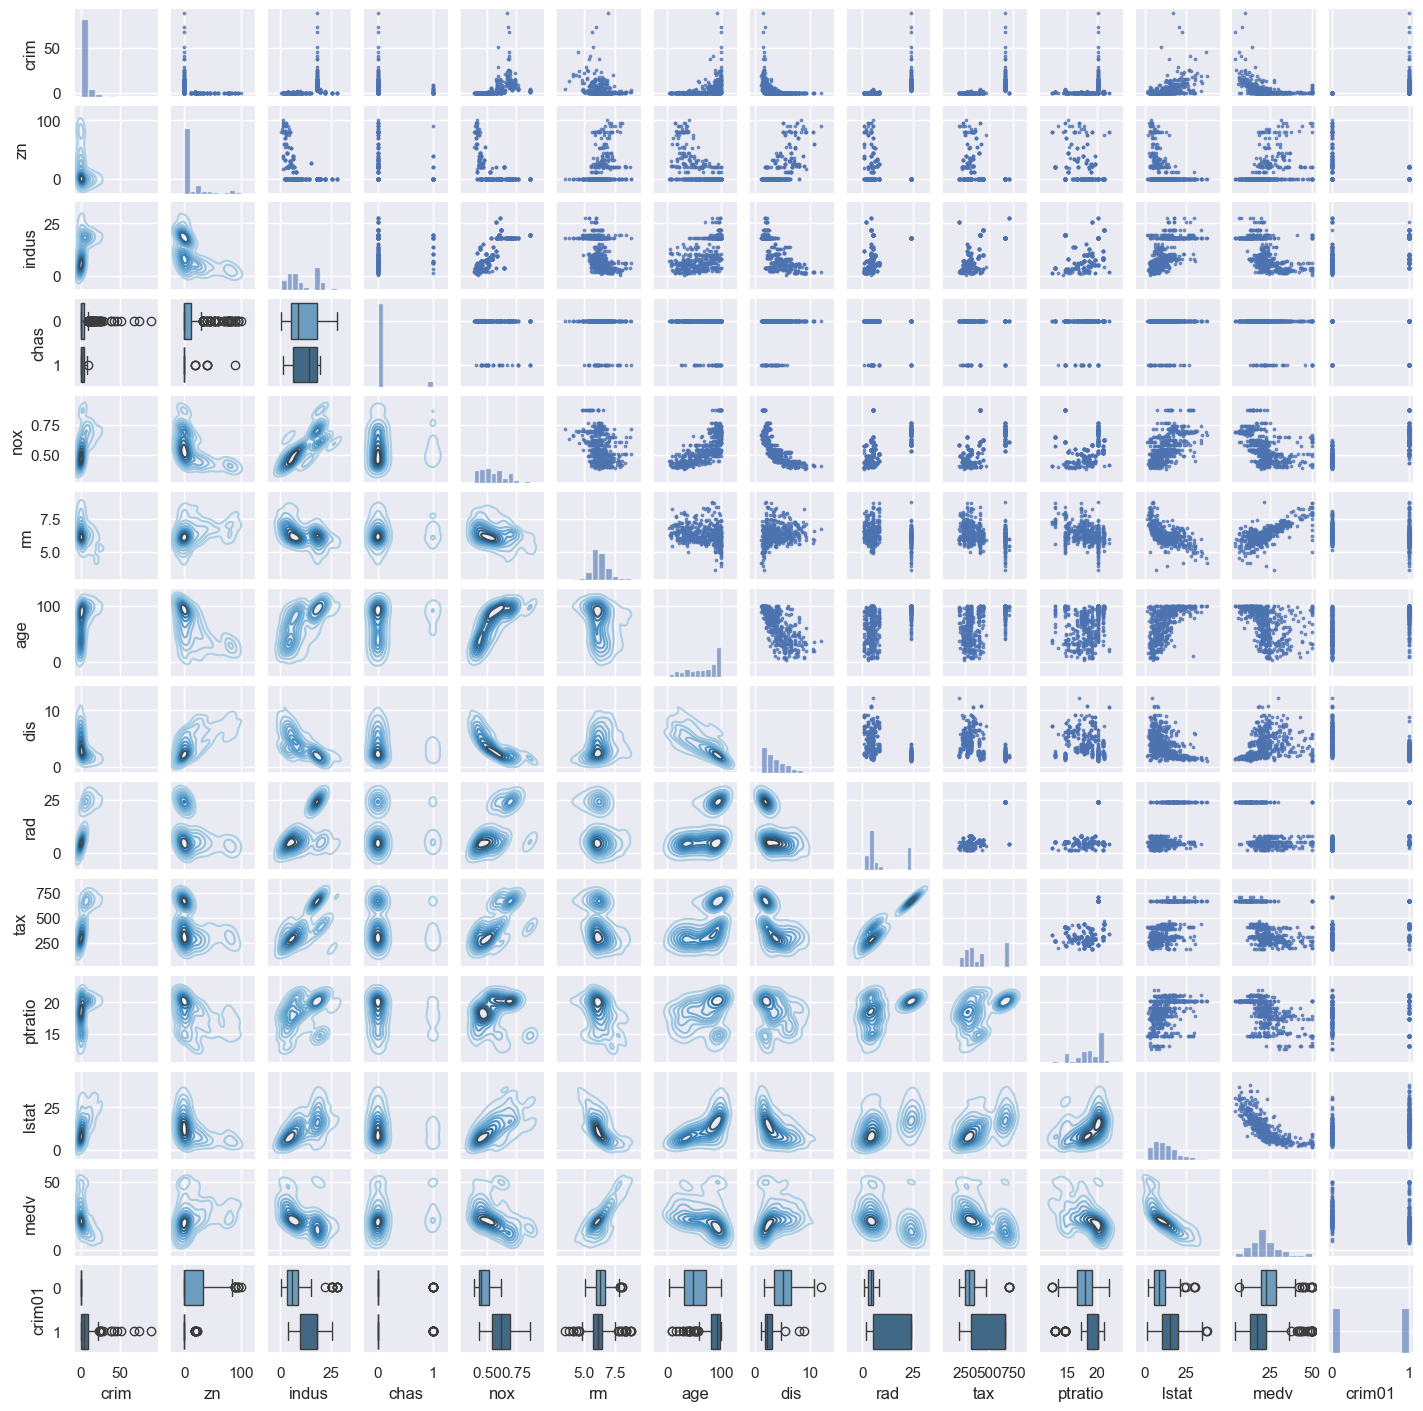

In [8]:
g = sns.PairGrid(boston)
g.map_upper(plt.scatter, s=3, alpha=0.7)
g.map_diag(plt.hist, alpha=0.6)

def lower_plots(x, y, **kwargs):
    if y.name in ['crim01', 'chas']: 
        num_colors_needed = y.nunique()
        sns.boxplot(x=x, y=y, orient='h', hue=y, palette=sns.color_palette('Blues_d', n_colors=num_colors_needed), **kwargs)  # Horizontal boxplot
    else:
        sns.kdeplot(x=x, y=y, cmap='Blues_d', **kwargs)  # KDE plot

g.map_lower(lower_plots)
g.figure.set_size_inches(14, 14);

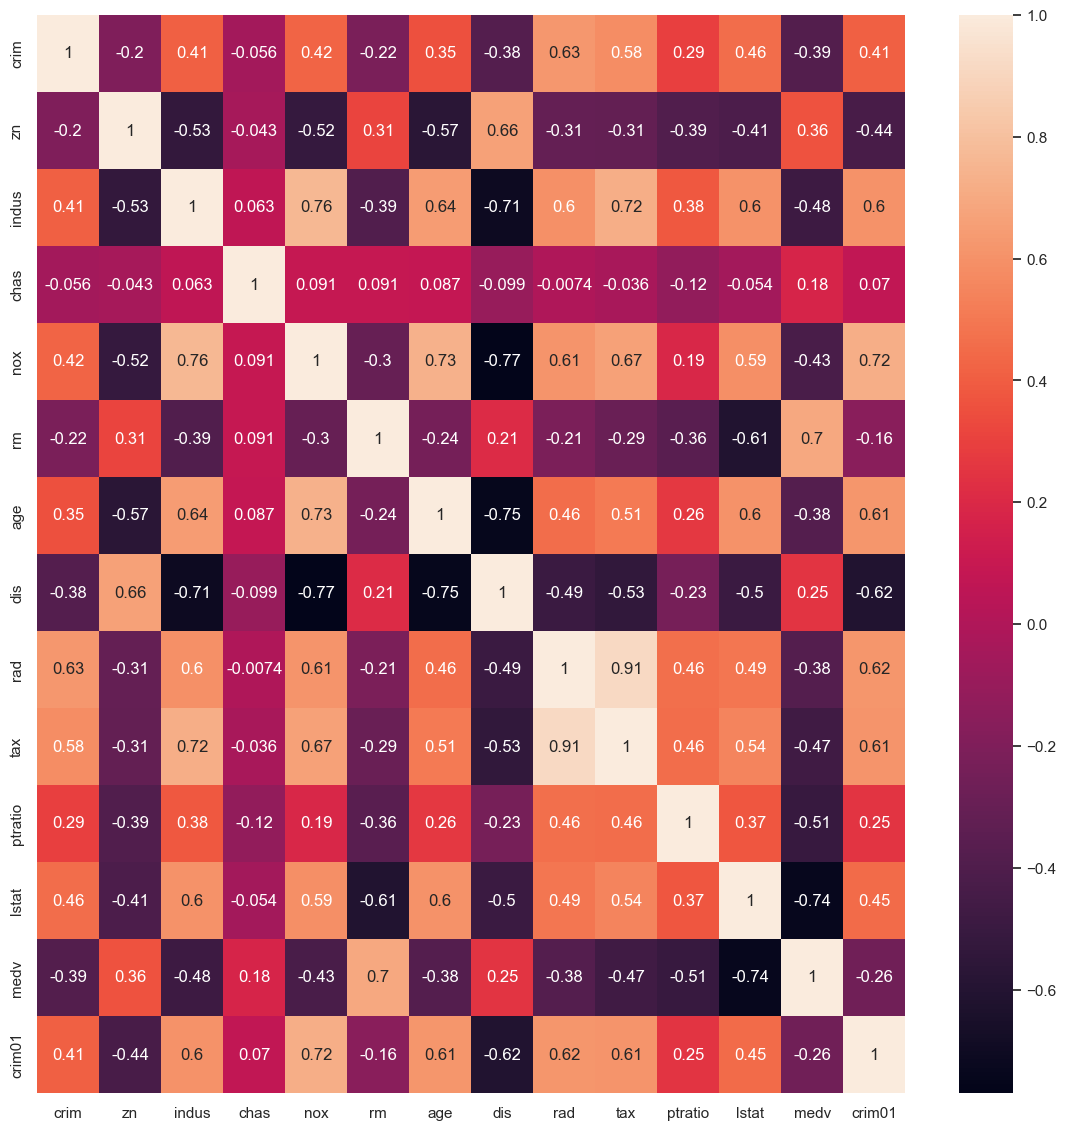

In [9]:
plt.figure(figsize=(14, 14))
sns.heatmap(boston.corr(), annot=True);

Looking at the heatmap and the plots, I decided to use the variables `indus`, `nox`, `age`, `dis`, `rad`, `tax` because seem to have strong relationships with `crim01`.

In [20]:
X = boston[['indus', 'nox', 'age', 'dis', 'rad', 'tax']]
y = boston['crim01']

In [21]:
def fit_and_get_error_rate(model, X, y):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
    
    mdl = model
    
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    conf_mat = confusion_table(pred, y_test)
    return get_error_rate(conf_mat)

Using the function above on the 4 models to fit them and get their error rates:

In [22]:
for model in [LDA(), QDA(), LogisticRegression(max_iter=1000), GaussianNB()]:
    print(f'{model.__str__().split("(")[0]}: {fit_and_get_error_rate(model, X, y)}\n')

NameError: name 'get_error_rate' is not defined

We can see the test error rate for each of the models and see that QDA performed the best here with a test error rate of **12.5%**.

Now to fit the KNN classifier we'll start by standardizing the data.

In [15]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)

X_std = scaler.fit_transform(X)

feature_std = pd.DataFrame(
                 X_std,
                 columns=X.columns);

feature_std.std()

indus    1.00099
nox      1.00099
age      1.00099
dis      1.00099
rad      1.00099
tax      1.00099
dtype: float64

In [16]:
X_train_std, X_test_std, y_train_std, y_test_std  = train_test_split(feature_std, y, test_size=0.4,random_state=1)

In [17]:
error_rate = {}
for k in range(1, 200):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_std, y_train_std)
    knn_pred = knn.predict(X_test_std)
    conf_mat = confusion_table(knn_pred, y_test_std)
    error_rate[k] = get_error_rate(conf_mat)

NameError: name 'get_error_rate' is not defined

ValueError: min() arg is an empty sequence

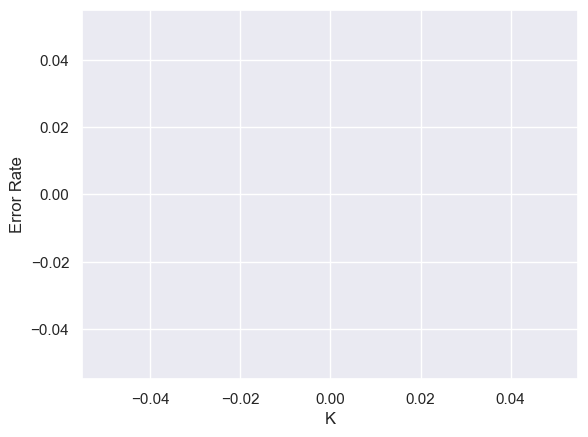

In [18]:
plt.plot(error_rate.keys(), error_rate.values())
plt.xlabel('K')
plt.ylabel('Error Rate');
k_min = min(error_rate, key=error_rate.get)
k_min, error_rate[k_min]

K = 6 seems to be the best value for the KNN classifier with a test error rate of **6.4%**.